# Notebook 3 — 3W Dataset Hodge Classification

This notebook compares three feature sets on the public
[3W dataset](https://github.com/petrobras/3W) for three-class flow-regime classification:

| Label | Regime | Count |
|---|---|---|
| 0 | Normal operation | 597 |
| 1 | Severe slugging | 106 |
| 2 | Flow instabilities | 344 |

## Feature sets compared

| Name | Features | Dimension |
|---|---|---|
| `baseline_scalar` | Max persistence, mean Betti, normalised persistence entropy (H₀ & H₁) | 6 |
| `hodge_only` | η_harm, η_grad, η_curl, harm/curl ratio, β₁, λ₁, spectral gap | 7 |
| `hodge_augmented` | baseline_scalar + hodge_only | 13 |

The persistence indicators match those used in
`../../Persistent_Homology/notebooks/06_machine_learning.ipynb` (Section 6):
`[max_pers_H0, max_pers_H1, mean_betti_H0, mean_betti_H1, entropy_norm_H0, entropy_norm_H1]`.

## Tools used

- **giotto-tda**: Takens embedding, VRP persistence, persistence entropy and Betti curves
- **Our Hodge module**: boundary matrices, decomposition, L₁ spectrum
- **scikit-learn**: RandomForest and LogisticRegression classifiers
- **GUDHI**: (optional) for cross-checking persistence diagrams via the simplex tree API

## Data setup

Download the 3W dataset and set `DATA_3W_ROOT` below:
```
git clone https://github.com/petrobras/3W   data/3w
```
The notebook expects directories like `data/3w/data/0/`, `data/3w/data/3/`, `data/3w/data/4/`.


## 1. Imports and paths

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path('..').resolve()))
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn import metrics

from gtda.time_series import TakensEmbedding, Resampler
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceEntropy, BettiCurve

from hodge.boundary_matrices import get_rips_simplices, build_boundary_matrices, pressure_to_1cochain
from hodge.decomposition import hodge_decomposition
from hodge.spectrum import compute_l1_spectrum
from utils.epsilon_selection import epsilon_from_diagram
from classification.feature_sets import FEATURE_SETS, REGIME_LABELS

# ── Path configuration ──────────────────────────────────────────────────────
DATA_3W_ROOT  = pathlib.Path("/Users/simo/Repos/TDA/Slugging/Data/3W_data")
LABEL_DIRS    = {0: DATA_3W_ROOT / "0",
                 1: DATA_3W_ROOT / "3",
                 2: DATA_3W_ROOT / "4"}
SENSOR_COL    = "P-TPT"    # wellhead pressure
N_RESAMPLE    = 8000       # resample each time series to this length
PA_TO_BAR     = 1e-5

# Sliding-window parameters for feature extraction
WINDOW_SIZE   = 1000                     # samples per window; must satisfy WINDOW_SIZE > (d-1)*τ
WINDOW_STRIDE = WINDOW_SIZE // 10        # 10 % of window length

## 2. Data loading and resampling

All CSV files for each class are loaded, missing values are interpolated, and each signal
is resampled to exactly `N_RESAMPLE` points so all time series are comparable regardless
of their original length.

> **Sensor used — `P-TPT` (Pressure at the Production Tubing Head):** this is the wellhead
> pressure measurement, i.e. the pressure recorded at the top of the production tubing where
> it meets the surface equipment. It is the sole input signal for the Takens embedding,
> persistent homology, and Hodge decomposition steps throughout this notebook.

In [2]:
def _to_fixed_length(sig, n):
    sig = np.asarray(sig, dtype=float).ravel()
    if len(sig) == n:
        return sig
    if len(sig) > n:
        return sig[:n]
    return np.interp(np.linspace(0, 1, n), np.linspace(0, 1, len(sig)), sig)


def load_class(label_dir, label, n=N_RESAMPLE):
    signals, names = [], []
    for f in sorted(label_dir.glob("*.csv")):
        df = pd.read_csv(f).infer_objects(copy=False).interpolate()
        if SENSOR_COL not in df.columns:
            continue
        sig = df[SENSOR_COL].dropna().values.astype(float)
        if len(sig) < 2:
            continue
        period = max(1, int(len(sig) / n))
        resampler = Resampler(period=period)
        _, sig_rs = resampler.fit_transform_resample(np.arange(len(sig)), sig)
        signals.append(_to_fixed_length(sig_rs, n) * PA_TO_BAR)
        names.append(f.stem)
    return signals, [label] * len(signals), names


USE_SYNTHETIC = not DATA_3W_ROOT.exists()

if USE_SYNTHETIC:
    print("3W data not found — generating synthetic placeholder dataset")
    rng = np.random.default_rng(0)
    all_signals, all_labels, all_names = [], [], []
    for label, (n_samples, amp, freq) in [
        (0, (200, 0.05, 0)), (1, (50, 3.0, 1/720)), (2, (100, 0.5, 1/120))
    ]:
        for i in range(n_samples):
            t = np.arange(N_RESAMPLE)
            s = 164 + rng.normal(0, amp, N_RESAMPLE)
            if freq > 0:
                s += amp * np.sin(2 * np.pi * freq * t)
            all_signals.append(s)
            all_labels.append(label)
            all_names.append(f"synthetic_class{label}_{i:04d}")
else:
    all_signals, all_labels, all_names = [], [], []
    for label, d in LABEL_DIRS.items():
        sigs, labs, nms = load_class(d, label)
        all_signals.extend(sigs)
        all_labels.extend(labs)
        all_names.extend(nms)

all_signals = np.array(all_signals)
all_labels  = np.array(all_labels)
all_names   = np.array(all_names)

_order      = np.argsort(all_labels, kind="stable")
all_signals = all_signals[_order]
all_labels  = all_labels[_order]
all_names   = all_names[_order]

for lab, name in REGIME_LABELS.items():
    print(f"  {name:25s}: {(all_labels == lab).sum():4d} files")
print(f"Total: {len(all_labels)} files × {N_RESAMPLE} time steps each")

  normal                   :  597 files
  severe_slugging          :  106 files
  flow_instabilities       :  344 files
Total: 1047 files × 8000 time steps each


## 3. Embedding parameters

Class-specific Takens embedding parameters (τ, d) are determined from the **first loaded
signal of each class** — already resampled to `N_RESAMPLE` points — so the parameters are
calibrated on exactly the signal length the feature extractor will see.

Each candidate is validated against `WINDOW_SIZE`: the constraint `WINDOW_SIZE > (d − 1) × τ`
must hold so that at least one embedded point fits per window.

In [3]:
from gtda.time_series import SingleTakensEmbedding

EMBED_STRIDE = 3


def check_embedding_params(n_samples, time_delay, dimension):
    max_embed_length = n_samples - (dimension - 1) * time_delay
    if max_embed_length <= 0:
        raise ValueError(
            f"Embedding params (time_delay={time_delay}, dimension={dimension}) "
            f"incompatible with n_samples={n_samples}. "
            f"Max embedded length = {max_embed_length}."
        )
    return max_embed_length


def run_optimal_embedding_selection(signal, tau_max=100, dim_max=10):
    """Optimal (τ, d) via mutual-information minimisation and false-nearest-neighbours."""
    ste = SingleTakensEmbedding(
        parameters_type='search',
        time_delay=tau_max,
        dimension=dim_max,
        n_jobs=1,
    )
    ste.fit_transform(signal)
    return int(ste.dimension_), int(ste.time_delay_)


_DEFAULTS = {
    0: {"time_delay": 100, "dimension": 10},
    1: {"time_delay": 100, "dimension": 10},
    2: {"time_delay": 100, "dimension": 10},
}

_opt_embed = {}
for _label in sorted(LABEL_DIRS):
    _mask = (all_labels == _label)
    if not _mask.any():
        print(f"(label {_label}: no signals loaded — keeping defaults)")
        continue
    _sig = all_signals[_mask][0]   # first loaded signal, already resampled

    _d_opt, _tau_opt = run_optimal_embedding_selection(_sig)

    try:
        _n_pts = check_embedding_params(WINDOW_SIZE, time_delay=_tau_opt, dimension=_d_opt)
        print(f"label {_label} | {all_names[_mask][0]}: "
              f"dimension={_d_opt}, time_delay={_tau_opt}  → {_n_pts} embedded pts/window")
        _opt_embed[_label] = {"time_delay": _tau_opt, "dimension": _d_opt}
    except ValueError as e:
        print(f"WARNING label {_label}: {e}")
        print(f"  Keeping defaults.")

EMBED_PARAMS = {lbl: _opt_embed.get(lbl, _DEFAULTS[lbl]) for lbl in _DEFAULTS}

print("\nFinal EMBED_PARAMS (validated against WINDOW_SIZE={})".format(WINDOW_SIZE))
for lbl, params in EMBED_PARAMS.items():
    n = check_embedding_params(WINDOW_SIZE, **params)
    print(f"  label {lbl}: τ={params['time_delay']:3d}, d={params['dimension']}"
          f"  → {n} embedded pts/window")

label 0 | WELL-00001_20170201020207: dimension=5, time_delay=97  → 612 embedded pts/window
label 1 | SIMULATED_00001: dimension=9, time_delay=80  → 360 embedded pts/window
label 2 | WELL-00001_20170316120203: dimension=2, time_delay=80  → 920 embedded pts/window

Final EMBED_PARAMS (validated against WINDOW_SIZE=1000)
  label 0: τ= 97, d=5  → 612 embedded pts/window
  label 1: τ= 80, d=9  → 360 embedded pts/window
  label 2: τ= 80, d=2  → 920 embedded pts/window


## 4. Sliding-window tiling

One representative signal per class (first loaded file), showing:
- The resampled timeseries (gray line)
- All sliding windows as alternating shaded spans
- Takens embedding anchor points (red dots) across all windows

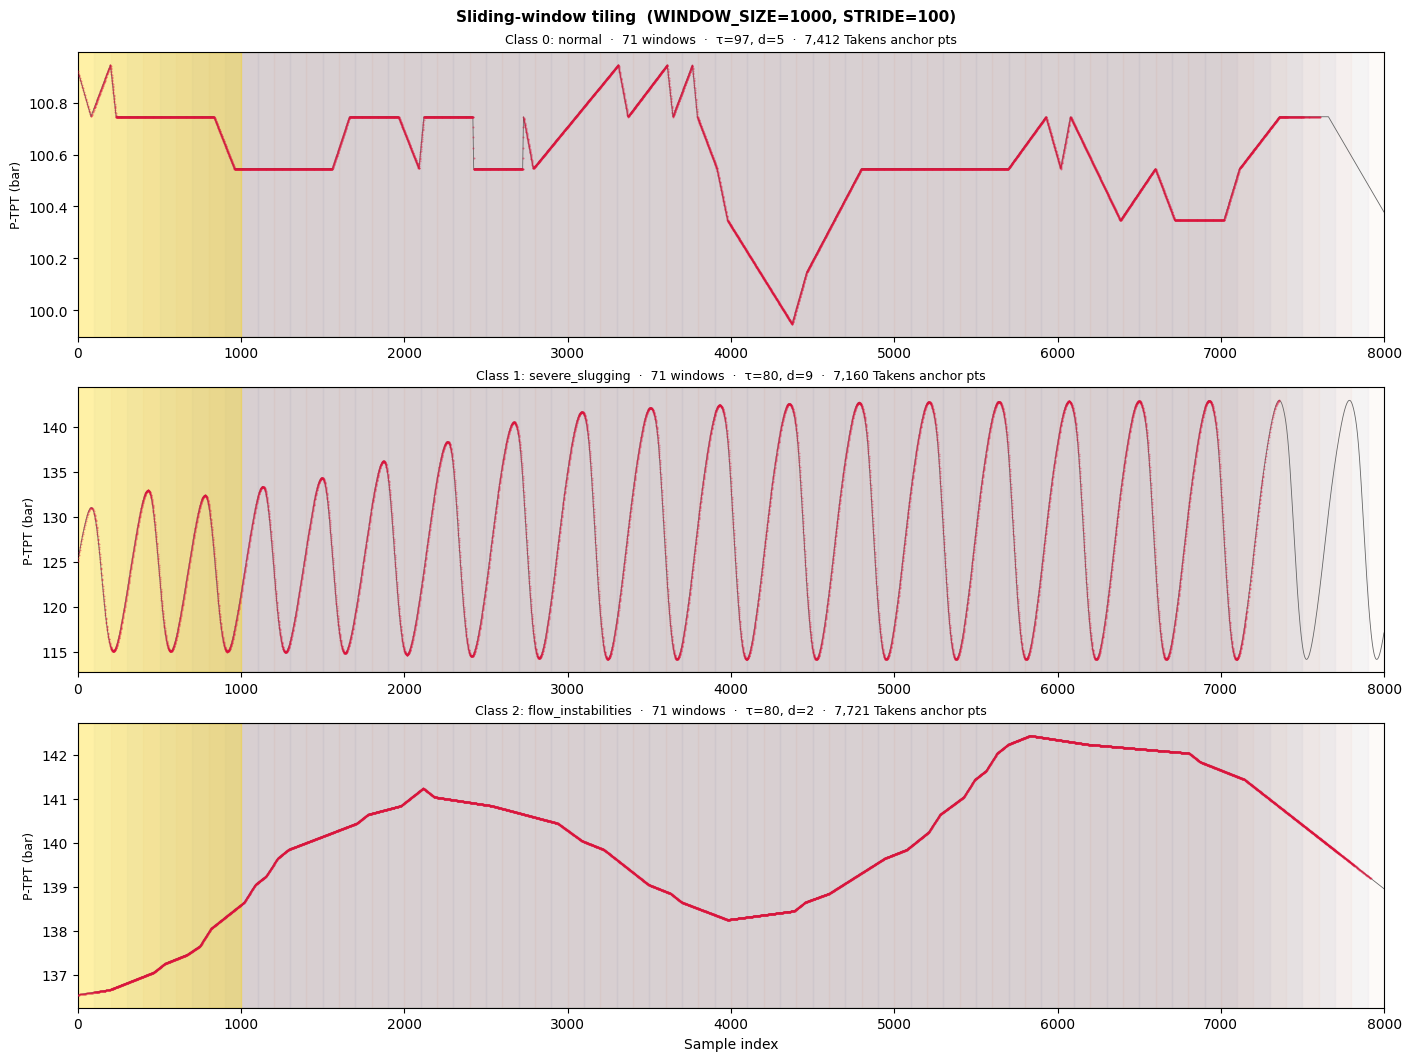

In [4]:
N_WINDOWS = (N_RESAMPLE - WINDOW_SIZE) // WINDOW_STRIDE + 1

fig, axes = plt.subplots(len(REGIME_LABELS), 1,
                         figsize=(14, 3.5 * len(REGIME_LABELS)),
                         constrained_layout=True)
span_colors = ["#4C72B0", "#DD8452"]

for ax, (label, name) in zip(axes, REGIME_LABELS.items()):
    mask = (all_labels == label)
    sig  = all_signals[mask][0]
    ep   = EMBED_PARAMS[label]
    τ, d = ep["time_delay"], ep["dimension"]

    t = np.arange(N_RESAMPLE)
    ax.plot(t, sig, lw=0.6, color="0.4", zorder=2)

    # First window highlighted in yellow
    ax.axvspan(0, WINDOW_SIZE, alpha=0.35, color="gold", zorder=1)

    # Remaining windows — alternating shaded spans
    for i, start in enumerate(range(WINDOW_STRIDE, N_RESAMPLE - WINDOW_SIZE + 1, WINDOW_STRIDE)):
        ax.axvspan(start, start + WINDOW_SIZE,
                   alpha=0.04, color=span_colors[i % 2], zorder=0)

    # Takens anchor points from all windows
    all_anchors = []
    for start in range(0, N_RESAMPLE - WINDOW_SIZE + 1, WINDOW_STRIDE):
        n_pts = max(0, (WINDOW_SIZE - (d - 1) * τ - 1) // EMBED_STRIDE + 1)
        anch  = start + np.arange(n_pts) * EMBED_STRIDE
        all_anchors.append(anch[anch < start + WINDOW_SIZE])
    all_anchors = np.unique(np.concatenate(all_anchors))
    all_anchors = all_anchors[all_anchors < N_RESAMPLE]
    ax.scatter(all_anchors, sig[all_anchors], s=2, color="crimson",
               alpha=0.5, linewidths=0, zorder=3)

    ax.set_ylabel("P-TPT (bar)", fontsize=9)
    ax.set_title(
        f"Class {label}: {name}  ·  {N_WINDOWS} windows"
        f"  ·  τ={τ}, d={d}  ·  {len(all_anchors):,} Takens anchor pts",
        fontsize=9,
    )
    ax.set_xlim(0, N_RESAMPLE)

axes[-1].set_xlabel("Sample index")
fig.suptitle(
    f"Sliding-window tiling  (WINDOW_SIZE={WINDOW_SIZE}, STRIDE={WINDOW_STRIDE})",
    fontsize=11, fontweight="bold",
)
plt.show()

## 5. Feature extraction

We extract features in two stages:

### Stage A — Persistence features (giotto-tda)
For each window: embed → compute VRP persistence diagram → extract scalars
(persistence entropy, max persistence, mean Betti curve).

### Stage B — Hodge features (our module)
For each window: use the *same* embedding → compute ε from diagram → build
simplicial complex → Hodge decomposition + L₁ spectrum.

Both stages share the Takens embedding, so the Hodge analysis is directly informed
by the topological scale identified in Stage A.

In [ ]:
def extract_features_one(signal, embed_params):
    """Extract all 14 features from one signal window."""
    te    = TakensEmbedding(stride=EMBED_STRIDE, **embed_params)
    cloud = te.fit_transform(signal.reshape(1, -1))[0]

    VRP  = VietorisRipsPersistence(homology_dimensions=[0, 1], infinity_values=1e10, n_jobs=1)
    diag = VRP.fit_transform(cloud[np.newaxis])[0]
    diag_3d = diag[np.newaxis]

    PE_n = PersistenceEntropy(normalize=True, nan_fill_value=0.0)
    BC   = BettiCurve()

    ent_norm = PE_n.fit_transform(diag_3d)[0]
    betti    = BC.fit_transform(diag_3d)[0]

    pers_h0 = [abs(p[1] - p[0]) for p in diag if p[2] == 0]
    pers_h1 = [abs(p[1] - p[0]) for p in diag if p[2] == 1]
    max_pers_h0 = float(max(pers_h0)) if pers_h0 else 0.0
    max_pers_h1 = float(max(pers_h1)) if pers_h1 else 0.0

    pers_feats = {
        "max_pers_h0":     max_pers_h0,
        "max_pers_h1":     max_pers_h1,
        "mean_betti0":     float(np.mean(betti[0])),
        "mean_betti1":     float(np.mean(betti[1])),
        "entropy_norm_h0": float(ent_norm[0]),
        "entropy_norm_h1": float(ent_norm[1]),
    }

    eps = epsilon_from_diagram(diag, strategy="most_persistent")
    zero_hodge = dict(eta_harm=0., eta_grad=0., eta_curl=0.,
                      harm_curl_ratio=0., beta1_hodge=0,
                      lambda1=0., lambda2=0., spectral_gap=0.)
    if eps is None:
        return {**pers_feats, **zero_hodge}

    sc = get_rips_simplices(cloud, eps, max_dim=2)
    if len(sc.edges) < 2 or len(sc.triangles) == 0:
        return {**pers_feats, **zero_hodge}

    B1, B2 = build_boundary_matrices(sc)
    n_nodes = len(sc.nodes)
    f1     = pressure_to_1cochain(signal[:n_nodes], sc)
    decomp = hodge_decomposition(f1, B1, B2)
    spec   = compute_l1_spectrum(B1, B2, n_eigs=min(15, len(sc.edges) - 2))

    return {**pers_feats,
            "eta_harm": decomp.eta_harm, "eta_grad": decomp.eta_grad,
            "eta_curl": decomp.eta_curl, "harm_curl_ratio": decomp.harm_curl_ratio,
            "beta1_hodge": spec.beta1_hodge,
            "lambda1": spec.lambda1, "lambda2": spec.lambda2,
            "spectral_gap": spec.spectral_gap}


def extract_features_windows(signal, embed_params,
                              window_size=WINDOW_SIZE, stride=WINDOW_STRIDE):
    """Slide a window over signal and extract features from each window."""
    τ, d = embed_params["time_delay"], embed_params["dimension"]
    min_pts = (d - 1) * τ + EMBED_STRIDE
    if window_size <= min_pts:
        raise ValueError(
            f"WINDOW_SIZE={window_size} too small for τ={τ}, d={d} "
            f"(need > {min_pts}). Increase WINDOW_SIZE or reduce τ/d."
        )
    rows = []
    n = len(signal)
    for start in range(0, n - window_size + 1, stride):
        feats = extract_features_one(signal[start:start + window_size], embed_params)
        feats["window_start"] = start
        rows.append(feats)
    return pd.DataFrame(rows)


# ── Cache configuration (v3: one row per window) ───────────────────────────
CACHE_DIR     = pathlib.Path("../data")
PER_FILE_ROOT = CACHE_DIR / "nb03_features_P_TPT"
PER_FILE_ROOT.mkdir(parents=True, exist_ok=True)
FEATURE_CACHE = {lbl: CACHE_DIR / f"nb03_features_v3_class{lbl}.parquet"
                 for lbl in sorted(LABEL_DIRS)}
FORCE_RECOMPUTE = False

N_WINDOWS = (N_RESAMPLE - WINDOW_SIZE) // WINDOW_STRIDE + 1


def _per_file_path(label: int, name: str) -> pathlib.Path:
    d = PER_FILE_ROOT / f"class{label}"
    d.mkdir(parents=True, exist_ok=True)
    return d / f"{name}.parquet"


def _load_or_compute_windows(label, name, signal, embed_params):
    """Return a DataFrame of per-window features, using the per-file cache if valid."""
    p = _per_file_path(label, name)
    if p.exists() and not FORCE_RECOMPUTE:
        try:
            df = pd.read_parquet(p)
            if len(df) == N_WINDOWS:
                return df
        except Exception as e:
            print(f"  [class {label}] cache read error for {name} ({e}) — recomputing")
    df = extract_features_windows(signal, embed_params)
    df.to_parquet(p)
    return df


per_class_dfs = {}
for lbl in sorted(LABEL_DIRS):
    cache_path = FEATURE_CACHE[lbl]
    mask       = (all_labels == lbl)
    n_files    = int(mask.sum())
    n_expected = n_files * N_WINDOWS

    if cache_path.exists() and not FORCE_RECOMPUTE:
        cached = pd.read_parquet(cache_path)
        if len(cached) == n_expected:
            per_class_dfs[lbl] = cached
            print(f"[class {lbl}] loaded {len(cached)} rows "
                  f"({n_files} files × {N_WINDOWS} windows) from {cache_path.name}")
            continue
        print(f"[class {lbl}] cache size mismatch ({len(cached)} vs {n_expected}) — rebuilding")

    print(f"[class {lbl}] extracting: {n_files} files × {N_WINDOWS} windows …")
    sigs_lbl  = [sig for sig, l in zip(all_signals, all_labels) if l == lbl]
    names_lbl = [nm  for nm,  l in zip(all_names,  all_labels) if l == lbl]

    dfs = []
    n_cached = n_computed = 0
    for i, (nm, sig) in enumerate(zip(names_lbl, sigs_lbl), 1):
        p = _per_file_path(lbl, nm)
        had_cache = p.exists() and not FORCE_RECOMPUTE
        df_file = _load_or_compute_windows(lbl, nm, sig, EMBED_PARAMS[lbl])
        dfs.append(df_file.assign(file_name=nm, label=lbl))
        n_cached += had_cache
        n_computed += not had_cache
        if i % 10 == 0 or i == len(sigs_lbl):
            print(f"  [class {lbl}] {i}/{len(sigs_lbl)} files  "
                  f"(cached={n_cached}, computed={n_computed})")

    df_lbl = pd.concat(dfs, ignore_index=True)
    df_lbl.to_parquet(cache_path)
    per_class_dfs[lbl] = df_lbl
    print(f"[class {lbl}] saved {len(df_lbl)} rows to {cache_path.name}")

features_df = pd.concat(
    [per_class_dfs[lbl] for lbl in sorted(LABEL_DIRS)],
    ignore_index=True,
)

# Keep file-level arrays sorted by label to match features_df row order
_order      = np.argsort(all_labels, kind="stable")
all_signals = all_signals[_order]
all_labels  = all_labels[_order]
all_names   = all_names[_order]

print(f"\nFeature matrix: {features_df.shape}  "
      f"({len(all_labels)} files × {N_WINDOWS} windows × 14 features + meta)")
features_df.head()

[class 0] extracting: 597 files × 71 windows …
  [class 0] 10/597 files  (cached=10, computed=0)
  [class 0] 20/597 files  (cached=20, computed=0)
  [class 0] 30/597 files  (cached=30, computed=0)
  [class 0] 40/597 files  (cached=40, computed=0)
  [class 0] 50/597 files  (cached=50, computed=0)
  [class 0] 60/597 files  (cached=60, computed=0)
  [class 0] 70/597 files  (cached=70, computed=0)
  [class 0] 80/597 files  (cached=80, computed=0)
  [class 0] 90/597 files  (cached=90, computed=0)
  [class 0] 100/597 files  (cached=91, computed=9)
  [class 0] 110/597 files  (cached=91, computed=19)
  [class 0] 120/597 files  (cached=91, computed=29)
  [class 0] 130/597 files  (cached=91, computed=39)
  [class 0] 140/597 files  (cached=91, computed=49)
  [class 0] 150/597 files  (cached=91, computed=59)
  [class 0] 160/597 files  (cached=91, computed=69)
  [class 0] 170/597 files  (cached=91, computed=79)
  [class 0] 180/597 files  (cached=91, computed=89)
  [class 0] 190/597 files  (cached=9

## 6. Classification comparison

We use **10-fold stratified cross-validation** with two classifiers:
- **LogisticRegression** (saga solver, L2 penalty, standardised features)
- **RandomForestClassifier** (100 trees, no scaling needed)

Each feature set is evaluated independently.

In [ ]:
_meta_cols = {"window_start", "file_name", "label"}
feat_cols  = [c for c in features_df.columns if c not in _meta_cols]
X_all = features_df[feat_cols].values
y     = features_df["label"].values

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

results_table = []
for fs_name, fs_cols in FEATURE_SETS.items():
    available = [c for c in fs_cols if c in feat_cols]
    X = features_df[available].values

    for clf_name, clf in [
        ("LogReg",        make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, solver='saga'))),
        ("RandomForest",  RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=1)),
    ]:
        cv_res = cross_validate(clf, X, y, cv=cv,
                                scoring=["accuracy","f1_macro","recall_macro"],
                                return_train_score=False, n_jobs=1)
        results_table.append({
            "feature_set": fs_name,
            "classifier":  clf_name,
            "accuracy":    cv_res["test_accuracy"].mean(),
            "f1_macro":    cv_res["test_f1_macro"].mean(),
            "recall_macro":cv_res["test_recall_macro"].mean(),
        })

results_table = pd.DataFrame(results_table)
print(results_table.to_string(index=False, float_format="%.4f"))

## 7. Confusion matrix for best model

In [ ]:
from sklearn.model_selection import train_test_split

best_row = results_table.loc[results_table["f1_macro"].idxmax()]
print(f"Best: {best_row['classifier']} on '{best_row['feature_set']}' — F1={best_row['f1_macro']:.4f}")

best_cols = [c for c in FEATURE_SETS[best_row["feature_set"]] if c in features_df.columns]
X_best = features_df[best_cols].values

X_tr, X_te, y_tr, y_te = train_test_split(X_best, y, test_size=0.35, random_state=42, stratify=y)

if best_row["classifier"] == "RandomForest":
    best_clf = RandomForestClassifier(n_estimators=100, random_state=42)
else:
    best_clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, solver='saga'))

best_clf.fit(X_tr, y_tr)
y_pred = best_clf.predict(X_te)

cm   = metrics.confusion_matrix(y_te, y_pred)
disp = metrics.ConfusionMatrixDisplay(cm, display_labels=[REGIME_LABELS[i] for i in sorted(REGIME_LABELS)])
disp.plot(cmap='Blues')
plt.title(f"Best model: {best_row['classifier']} / {best_row['feature_set']}")
plt.tight_layout()
plt.show()

print(metrics.classification_report(y_te, y_pred, target_names=[REGIME_LABELS[i] for i in sorted(REGIME_LABELS)]))

## 8. Feature importance (Random Forest on hodge_augmented)

The Random Forest's Gini impurity measure tells us which features contribute most to
the classification decision. We expect `η_harm` and `spectral_gap` to rank highly
alongside the persistence-based features.

In [ ]:
aug_cols = [c for c in FEATURE_SETS["hodge_augmented"] if c in features_df.columns]
X_aug = features_df[aug_cols].values

rf_aug = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=1)
rf_aug.fit(*train_test_split(X_aug, y, test_size=0.35, random_state=42, stratify=y)[:2])

imp = pd.Series(rf_aug.feature_importances_, index=aug_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 5))
imp.plot.barh(ax=ax, color='steelblue')
ax.axvline(1 / len(aug_cols), ls='--', color='gray', lw=0.8, label='Uniform baseline')
ax.set_xlabel("Gini importance")
ax.set_title("Feature importances — hodge_augmented (Random Forest)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
